In [36]:
import pandas as pd
import matplotlib as plt

In [2]:
data = pd.read_csv("2titanic.csv")

In [3]:
#Leer los primeros 5 renglones de mi dataset
data.head()  #Cabin nos dice los datos nulos (Nan)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Para ver el tamaño del dataset, para ver cuantos renglones y columnas tenemos
data.shape

(891, 12)

In [6]:
#Funcion count nos permite saber cuantos elementos hay en cada columna
data.count()

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64

In [10]:

col_names = data.columns.tolist() #Convierte los nombres de las columnas en una lista 
#y las guarda 
col_names

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [15]:
for column in col_names:
    print("Valores nulos en:", column, ":", data[column].isnull().sum())

Valores nulos en: PassengerId : 0
Valores nulos en: Survived : 0
Valores nulos en: Pclass : 0
Valores nulos en: Name : 0
Valores nulos en: Sex : 0
Valores nulos en: Age : 177
Valores nulos en: SibSp : 0
Valores nulos en: Parch : 0
Valores nulos en: Ticket : 0
Valores nulos en: Fare : 0
Valores nulos en: Cabin : 687
Valores nulos en: Embarked : 2


In [16]:
#Vamos a revisar la estadistica descriptiva en mi data set
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [21]:
#Transformacion de datos creando una funcion, estra funcion va a recibir un diccionario y un valor y va a reotrnar el valor.
def sex_transform(x):
    d = {'male':'M', 'female':'F'}
    return(d[x])

data['Sex'] = data ['Sex'].apply(sex_transform)

In [22]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",M,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",F,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",F,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",M,35.0,0,0,373450,8.0500,NaN,S


In [23]:
#Copiar la columna sex a una nueva columna que se llame Gender

data['Gender'] = data['Sex']
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Gender
0,1,0,3,"Braund, Mr. Owen Harris",M,22.0,1,0,A/5 21171,7.2500,NaN,S,M
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",F,38.0,1,0,PC 17599,71.2833,C85,C,F
2,3,1,3,"Heikkinen, Miss. Laina",F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,F
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",F,35.0,1,0,113803,53.1000,C123,S,F
4,5,0,3,"Allen, Mr. William Henry",M,35.0,0,0,373450,8.0500,NaN,S,M


# Exploracion de datos 

In [25]:
# Cuantas y cuales pasajeros se subieron sin pagar?

data[data.Fare == 0 ] #Tambien se puede acceder con data.Fare

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Gender
179,180,0,3,"Leonard, Mr. Lionel",M,36.0,0,0,LINE,0.0,NaN,S,M
263,264,0,1,"Harrison, Mr. William",M,40.0,0,0,112059,0.0,B94,S,M
271,272,1,3,"Tornquist, Mr. William Henry",M,25.0,0,0,LINE,0.0,NaN,S,M
277,278,0,2,"Parkes, Mr. Francis ""Frank""",M,NaN,0,0,239853,0.0,NaN,S,M
302,303,0,3,"Johnson, Mr. William Cahoone Jr",M,19.0,0,0,LINE,0.0,NaN,S,M
413,414,0,2,"Cunningham, Mr. Alfred Fleming",M,NaN,0,0,239853,0.0,NaN,S,M
466,467,0,2,"Campbell, Mr. William",M,NaN,0,0,239853,0.0,NaN,S,M
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",M,NaN,0,0,239854,0.0,NaN,S,M
597,598,0,3,"Johnson, Mr. Alfred",M,49.0,0,0,LINE,0.0,NaN,S,M
633,634,0,1,"Parr, Mr. William Henry Marsh",M,NaN,0,0,112052,0.0,NaN,S,M


In [26]:
# Tabla cruzada entre supervivencia y sexo 
pd.crosstab(data.Survived, data.Sex)

Sex,F,M
Survived,,
0,81,468
1,233,109


In [30]:
# Agrupar los datos por clase y sexo, despues solo mostrar la suma de los que sobrevivieron 
pclass_sex_survival_count = data.groupby(['Pclass','Sex'])['Survived'].sum()
pclass_sex_survival_count

Pclass  Sex
1       F      91
        M      45
2       F      70
        M      17
3       F      72
        M      47
Name: Survived, dtype: int64

In [32]:
# Tabla cruzada entre PClass y Sexo
pd.crosstab(data.Pclass, data.Sex)

Sex,F,M
Pclass,,
1,94,122
2,76,108
3,144,347


Text(0.5, 1.0, 'Sobrevivieron / cuenta total')

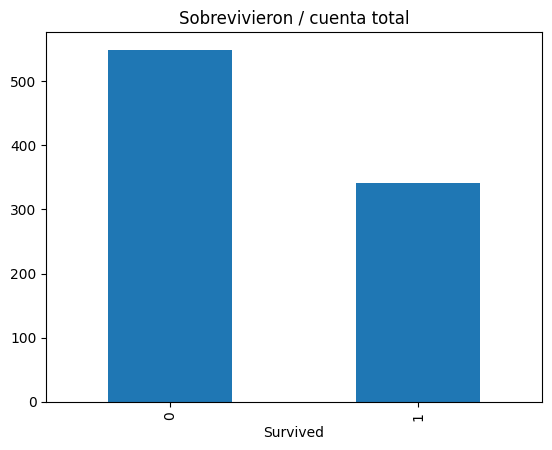

In [42]:
#Grafica de la columna survived
import matplotlib.pyplot as plt
data.Survived.value_counts().plot(kind = 'bar')
plt.title("Sobrevivieron / cuenta total")

Text(0.5, 1.0, 'Sobrevivieron / porcentaje total')

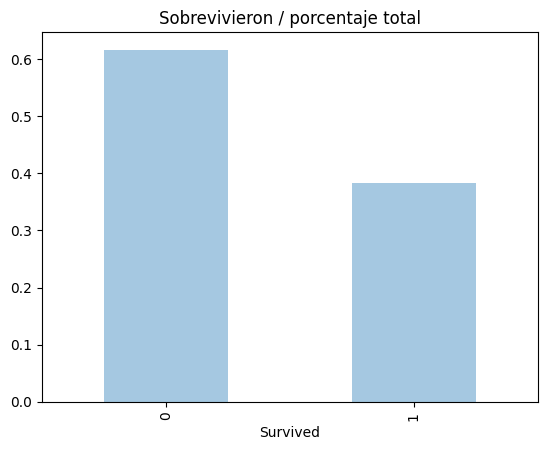

In [44]:
#Grafica de la columna survived por porcentaje

data.Survived.value_counts(normalize = True).plot(kind = 'bar' , alpha = 0.4)
plt.title('Sobrevivieron / porcentaje total')

Text(0.5, 1.0, 'Sobrevivieron totales - M vs F')

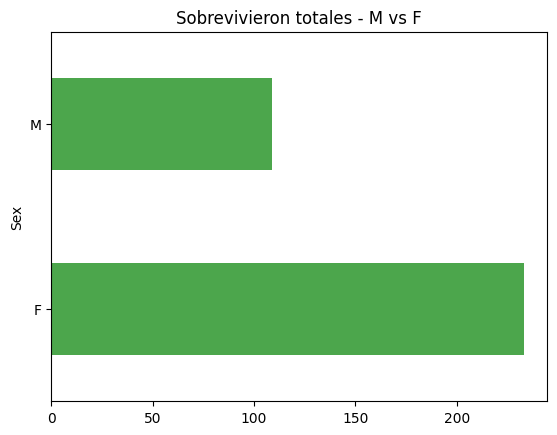

In [45]:
# Grafica de sexo y survives en cuenta total
data.Sex[data.Survived ==1].value_counts().plot(kind = 'barh',color = "green", alpha = 0.7)
plt.title('Sobrevivieron totales - M vs F')

Text(0.5, 1.0, 'Sobrevivieron porcentajes M vs F')

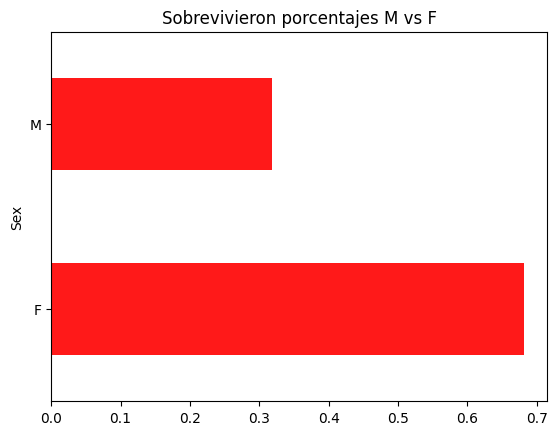

In [46]:
#Grafica de sexo y sobrevivientes en porcentajes
data.Sex[data.Survived == 1].value_counts(normalize = True).plot(kind = 'barh', color = 'red', alpha = 0.9)
plt.title("Sobrevivieron porcentajes M vs F")

Text(0.5, 1.0, 'Sobrevivientes por clase - Totales')

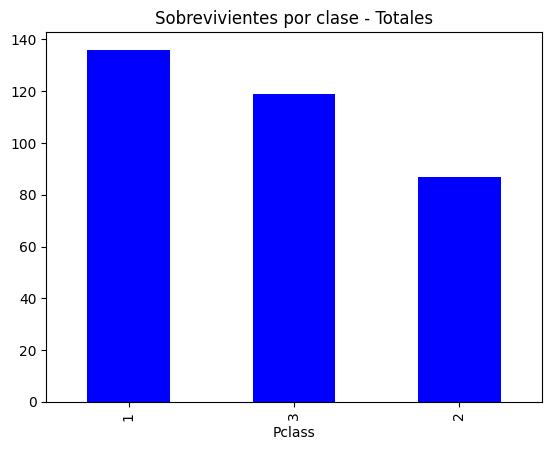

In [52]:
#Grafica survives por clase
data.Pclass[data.Survived == 1].value_counts().plot(kind = 'bar', color = 'blue')
plt.title("Sobrevivientes por clase - Totales")

Text(0.5, 1.0, 'Sobrevivientes por clase - Porcentajes')

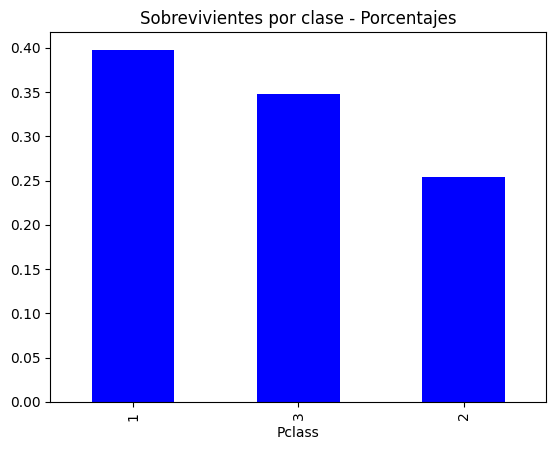

In [53]:
#Grafica survives por clase
data.Pclass[data.Survived == 1].value_counts(normalize = True).plot(kind = 'bar', color = 'blue')
plt.title("Sobrevivientes por clase - Porcentajes")

Text(0.5, 1.0, 'Sobrevivientes por clase - Porcentajes')

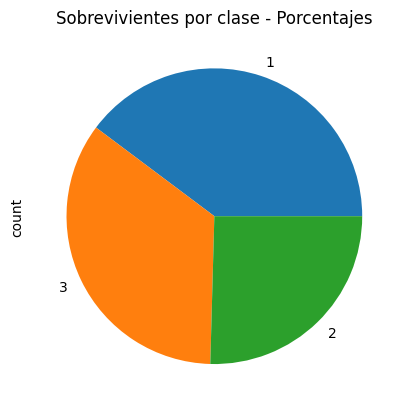

In [55]:
#Grafica por clase en porcentajes - pastel
#Grafica survives por clase
data.Pclass[data.Survived == 1].value_counts().plot(kind = 'pie')
plt.title("Sobrevivientes por clase - Porcentajes")

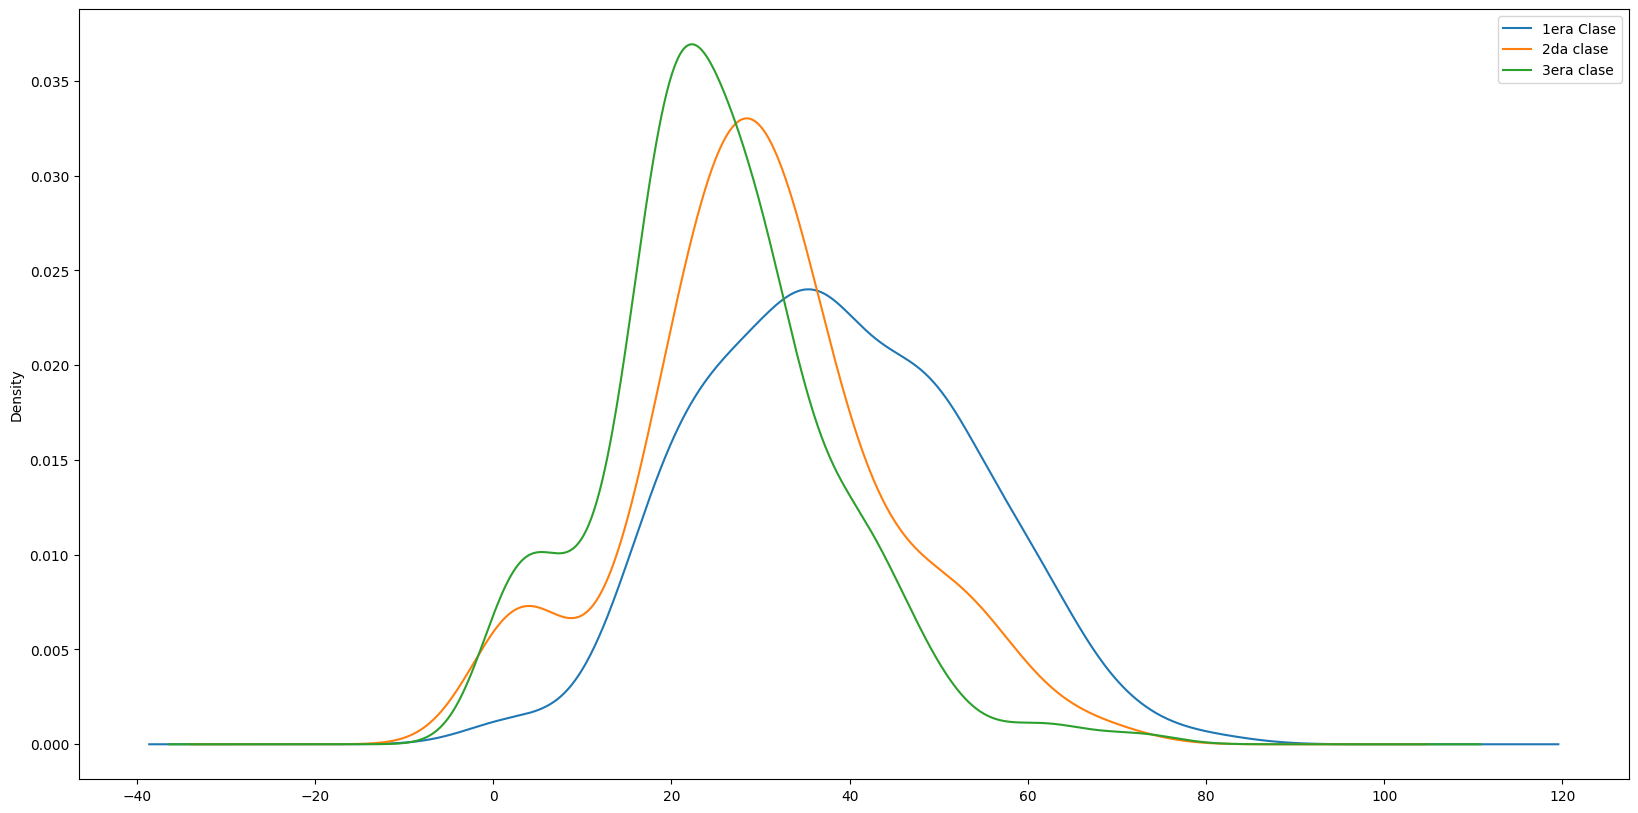

In [59]:
#Grafica de dispercion - nueva grafica para ver si hay una relacion entre tipo de ticket ye dad
fig = plt.figure(figsize= (20,10))
for clase in [1,2,3]:
    data.Age[data.Pclass == clase].plot(kind = 'kde')
    plt.legend(("1era Clase", "2da clase","3era clase"))

In [60]:
# Cuantos pasajeros eran menores de 1 año
data[data.Age < 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Gender
78,79,1,2,"Caldwell, Master. Alden Gates",M,0.83,0,2,248738,29.0000,NaN,S,M
305,306,1,1,"Allison, Master. Hudson Trevor",M,0.92,1,2,113781,151.5500,C22 C26,S,M
469,470,1,3,"Baclini, Miss. Helene Barbara",F,0.75,2,1,2666,19.2583,NaN,C,F
644,645,1,3,"Baclini, Miss. Eugenie",F,0.75,2,1,2666,19.2583,NaN,C,F
755,756,1,2,"Hamalainen, Master. Viljo",M,0.67,1,1,250649,14.5000,NaN,S,M
803,804,1,3,"Thomas, Master. Assad Alexander",M,0.42,0,1,2625,8.5167,NaN,C,M
831,832,1,2,"Richards, Master. George Sibley",M,0.83,1,1,29106,18.7500,NaN,S,M


In [61]:
# Informacion de la persona que pagó más al subirse
data[data.Fare > 510]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Gender
258,259,1,1,"Ward, Miss. Anna",F,35.0,0,0,PC 17755,512.3292,NaN,C,F
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",M,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,M
737,738,1,1,"Lesurer, Mr. Gustave J",M,35.0,0,0,PC 17755,512.3292,B101,C,M
